In [1]:
!pip install -q kaggle


In [2]:
!kaggle datasets download -d brandao/diabetes


Dataset URL: https://www.kaggle.com/datasets/brandao/diabetes
License(s): CC0-1.0
100% 4.41M/4.41M [00:00<00:00, 49.7MB/s]



In [3]:
!unzip -o diabetes.zip


Archive:  diabetes.zip
  inflating: description.pdf         
  inflating: diabetic_data.csv       


In [4]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df["readmitted"].value_counts())

Dataset Shape: (101766, 50)

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender               

In [6]:
# Display basic statistical information

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983458,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


In [7]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Create binary target variable for 30-day readmission

df["readmitted_30_days"] = (df["readmitted"] == "<30").astype(int)

# Check the new target distribution
print("30-Day Readmission Distribution:")
print(df["readmitted_30_days"].value_counts())

print("\nPercentage Distribution:")
print(df["readmitted_30_days"].value_counts(normalize=True) * 100)

30-Day Readmission Distribution:
readmitted_30_days
0    90409
1    11357
Name: count, dtype: int64

Percentage Distribution:
readmitted_30_days
0    88.840084
1    11.159916
Name: proportion, dtype: float64


In [9]:
# Remove identifier and original target columns

columns_to_drop = [
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

df_model = df.drop(columns=columns_to_drop)

print("New dataset shape:", df_model.shape)
print("\nRemaining columns:")
print(df_model.columns.tolist())

New dataset shape: (101766, 48)

Remaining columns:
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted_30_days']


In [10]:
# Remove columns with a very high percentage of missing values

high_missing_columns = [
    "weight",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult"
]

df_model = df_model.drop(columns=high_missing_columns)

print("Dataset shape after removing highly-missing columns:")
print(df_model.shape)

Dataset shape after removing highly-missing columns:
(101766, 43)


In [11]:
# Replace '?' with NaN

import numpy as np

df_model = df_model.replace("?", np.nan)

print("Remaining missing values:")
print(df_model.isnull().sum().sort_values(ascending=False).head(15))

Remaining missing values:
race                        2273
diag_3                      1423
diag_2                       358
diag_1                        21
admission_type_id              0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
discharge_disposition_id       0
gender                         0
age                            0
number_outpatient              0
num_medications                0
num_procedures                 0
number_inpatient               0
dtype: int64


In [12]:
print("Final target distribution:")
print(df_model["readmitted_30_days"].value_counts())

print("\nTarget percentages:")
print(
    df_model["readmitted_30_days"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Final target distribution:
readmitted_30_days
0    90409
1    11357
Name: count, dtype: int64

Target percentages:
readmitted_30_days
0    88.84
1    11.16
Name: proportion, dtype: float64


In [13]:
# Select features for the prediction model

selected_features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "diag_1",
    "diag_2",
    "diag_3",
    "insulin",
    "change",
    "diabetesMed"
]

X = df_model[selected_features]
y = df_model["readmitted_30_days"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (101766, 20)
Target shape: (101766,)

Features:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'diag_1', 'diag_2', 'diag_3', 'insulin', 'change', 'diabetesMed']


In [14]:
# Check missing values in selected features

print(X.isnull().sum().sort_values(ascending=False))

race                        2273
diag_3                      1423
diag_2                       358
diag_1                        21
admission_type_id              0
age                            0
gender                         0
discharge_disposition_id       0
num_procedures                 0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
number_emergency               0
number_outpatient              0
num_medications                0
number_diagnoses               0
number_inpatient               0
insulin                        0
change                         0
diabetesMed                    0
dtype: int64


In [15]:
# Preview the features

X.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,diag_1,diag_2,diag_3,insulin,change,diabetesMed
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,1,250.83,NaN,NaN,No,No,No
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,9,276,250.01,255,Up,Ch,Yes
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,6,648,250,V27,No,No,Yes
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,7,8,250.43,403,Up,Ch,Yes
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,5,197,157,250,Steady,Ch,Yes


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (81412, 20)
Testing set: (20354, 20)

Training target distribution:
readmitted_30_days
0    72326
1     9086
Name: count, dtype: int64

Testing target distribution:
readmitted_30_days
0    18083
1     2271
Name: count, dtype: int64


In [17]:
# Define numerical and categorical features

numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "diag_1",
    "diag_2",
    "diag_3",
    "insulin",
    "change",
    "diabetesMed"
]

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 8
Number of categorical features: 12


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=10
    ))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [19]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    solver="liblinear"
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [20]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", logistic_model)
])

print("Complete ML pipeline created successfully.")

Complete ML pipeline created successfully.


In [21]:
print("Training the model...")

model.fit(X_train, y_train)

print("Model training completed!")

Training the model...
Model training completed!


In [22]:
# Make predictions on the test set

y_pred = model.predict(X_test)

# Probability of 30-day readmission
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob[:10])

First 10 predicted classes:
[1 0 1 1 1 0 0 0 1 1]

First 10 predicted probabilities:
[0.53835669 0.32348032 0.69580121 0.68916925 0.68428148 0.28425012
 0.31138193 0.31291219 0.87942811 0.61227802]


In [23]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.6734


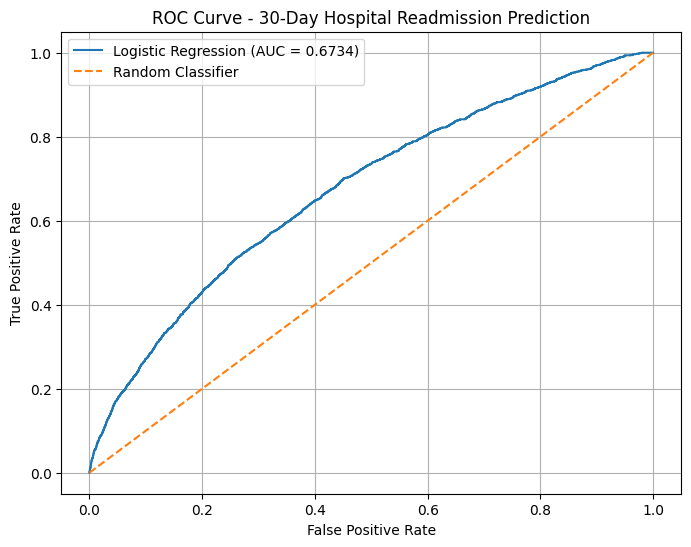

In [24]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission Prediction")

plt.legend()
plt.grid(True)
plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.6596
Precision: 0.1800
Recall   : 0.5768
F1-Score : 0.2744

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78     18083
           1       0.18      0.58      0.27      2271

    accuracy                           0.66     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.66      0.72     20354



Confusion Matrix:
[[12116  5967]
 [  961  1310]]


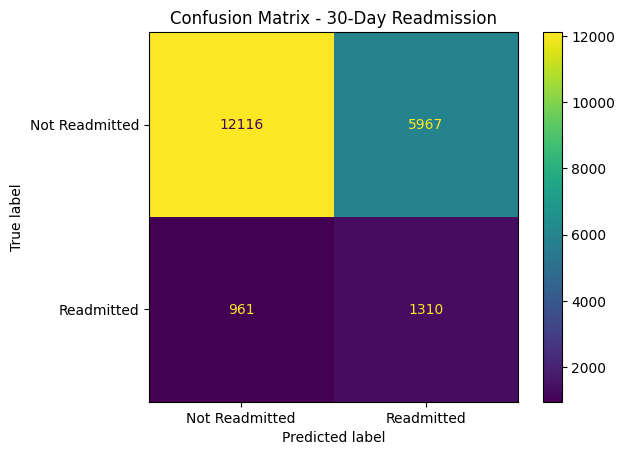

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("Confusion Matrix - 30-Day Readmission")
plt.show()

In [27]:
TN, FP, FN, TP = cm.ravel()

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

True Negatives : 12116
False Positives: 5967
False Negatives: 961
True Positives : 1310


In [28]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.6734


In [29]:
import pandas as pd
from sklearn.metrics import confusion_matrix

thresholds_to_test = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    specificity = tn / (tn + fp)

    results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Recall": recall,
        "Precision": precision,
        "Specificity": specificity
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,TN,FP,FN,TP,Recall,Precision,Specificity
0,0.2,1109,16974,28,2243,0.987671,0.116720,0.061328
1,0.3,3179,14904,156,2115,0.931308,0.124273,0.175800
2,0.4,7530,10553,468,1803,0.793923,0.145921,0.416413
3,0.5,12116,5967,961,1310,0.576838,0.180019,0.670022
4,0.6,15246,2837,1440,831,0.365918,0.226554,0.843112
5,0.7,16984,1099,1827,444,0.195509,0.287751,0.939225


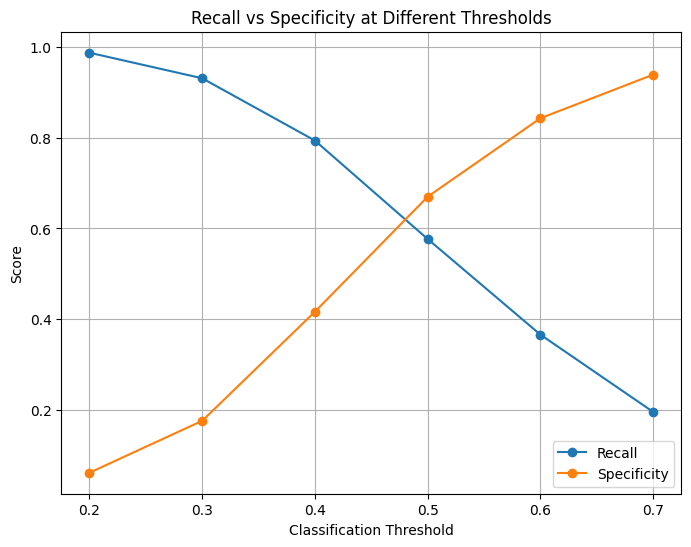

In [30]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Specificity"],
    marker="o",
    label="Specificity"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Recall vs Specificity at Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Calculate error rates for the baseline model

false_negative_rate = FN / (FN + TP)
false_positive_rate = FP / (FP + TN)

print(f"False Negative Rate: {false_negative_rate:.4f}")
print(f"False Positive Rate: {false_positive_rate:.4f}")

False Negative Rate: 0.4232
False Positive Rate: 0.3300
